
# 🌍 Climate & Health Risk Prediction Challenge - Starter Notebook (with Climate Enrichment)

Welcome to the starter notebook for this challenge.

In this challenge, your goal is to build a machine learning model that predicts whether a recorded death falls into a **climate-sensitive category**.

This notebook shows a baseline workflow that combines:

- the main competition data (`Train.csv`, `Test.csv`)
- the downloaded climate and environmental features (`climate_features_rich.csv`)

The notebook covers:

- Loading and merging the datasets
- Exploratory data analysis
- Preprocessing and feature engineering
- Training a baseline classifier
- Evaluating with the official metric:
  - **Final Score = 0.60 × F1 + 0.40 × ROC-AUC**
- Creating a submission file with the required columns:
  - `ID`
  - `TargetF1`
  - `TargetRAUC`

This notebook is designed to be beginner-friendly. You are encouraged to improve it with stronger models, richer feature engineering, and better validation.


In [2]:

# 📚 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


In [3]:

# 📥 Load the main competition data
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

# 📥 Load downloaded climate/environmental features
# This file should contain one row per ID
climate_features = pd.read_csv("climate_features.csv")

ID_COL = "ID"
TARGET = "is_climate_sensitive"
TARGET_F1 = "TargetF1"
TARGET_RAUC = "TargetRAUC"

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Climate feature shape:", climate_features.shape)

train.head()


Train shape: (3146, 13)
Test shape: (1030, 12)
Climate feature shape: (4176, 18)


,ID,zone,gender,deathdate,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,location,is_climate_sensitive
0,ID_1FE951BD,Rural,Male,2007-10-02,30.0,21.137037,25.569017,18.451642,0.951601,0.584646,33.546344,"Izimba, Iganga, Uganda",1
1,ID_5927A443,Rural,Male,2008-01-05,2.0,24.062790,29.312026,18.977212,0.053352,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
2,ID_C4E67025,Rural,Female,2008-02-14,31.0,22.407868,26.746058,18.112977,0.090349,0.573420,33.483655,"Buluza, Iganga, Uganda",1
3,ID_44DC5CE9,Rural,Female,2008-02-15,1.0,23.315198,28.056889,18.955708,0.286814,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
4,ID_33C677BB,Rural,Female,2008-02-15,69.0,23.315198,28.056889,18.955708,0.286814,1.072343,34.226647,"Magada, Mbale City, Bugisa sub-region, Eastern...",0



## 🔗 Merge climate features

We merge the downloaded climate and environmental features back into the training and test data using `ID`.


In [4]:
## Drop deathdate from climate_features
climate_features = climate_features.drop(columns=["deathdate"])

In [5]:

# Merge on ID
train = train.merge(climate_features, on=ID_COL, how="left")
test = test.merge(climate_features, on=ID_COL, how="left")

print("Train shape after merge:", train.shape)
print("Test shape after merge:", test.shape)

# Create a sample submission template from the test IDs
sample_submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET_F1: 0,
    TARGET_RAUC: 0.5
})

sample_submission.head()


Train shape after merge: (3146, 29)
Test shape after merge: (1030, 28)


,ID,TargetF1,TargetRAUC
0,ID_E760D84B,0,0.5
1,ID_6EDEA907,0,0.5
2,ID_B9FFC8D8,0,0.5
3,ID_74C6C94E,0,0.5
4,ID_0E02825D,0,0.5



## 🔍 Exploratory Data Analysis (EDA)

Let’s inspect the merged training data, check missing values, and understand the target distribution.


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3146 entries, 0 to 3145
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3146 non-null   object 
 1   zone                  3146 non-null   object 
 2   gender                3146 non-null   object 
 3   deathdate             3146 non-null   object 
 4   age                   3146 non-null   float64
 5   avg_temperature       3146 non-null   float64
 6   max_temperature       3146 non-null   float64
 7   min_temperature       3146 non-null   float64
 8   precipitation         3146 non-null   float64
 9   latitude              3146 non-null   float64
 10  longitude             3146 non-null   float64
 11  location              3146 non-null   object 
 12  is_climate_sensitive  3146 non-null   int64  
 13  elevation             3146 non-null   int64  
 14  hot_days_30d          3146 non-null   int64  
 15  max_daily_rain_30d   

In [7]:

# Missing values summary
missing_summary = train.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(30)


Series([], dtype: int64)

In [8]:

# Target distribution
train[TARGET].value_counts(normalize=True)


is_climate_sensitive
1    0.650668
0    0.349332
Name: proportion, dtype: float64

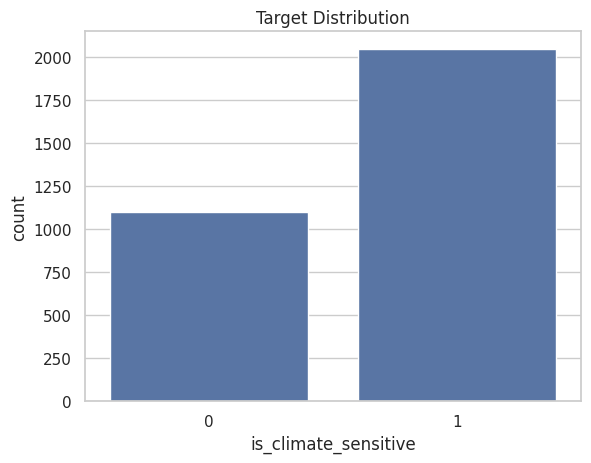

In [9]:

sns.countplot(x=TARGET, data=train)
plt.title("Target Distribution")
plt.show()


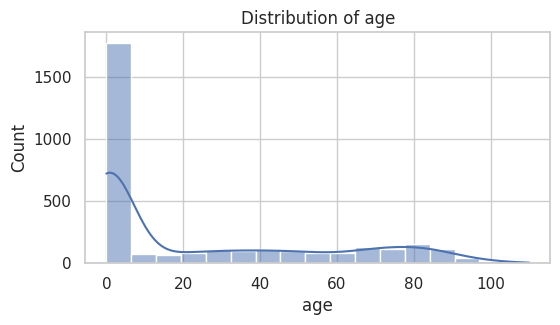

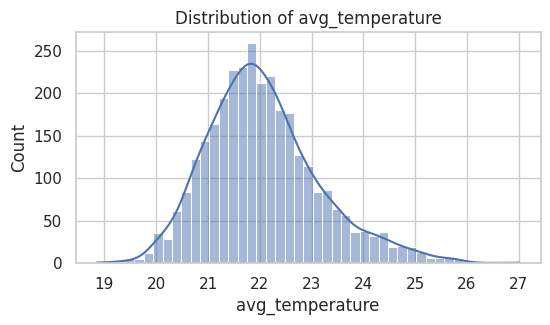

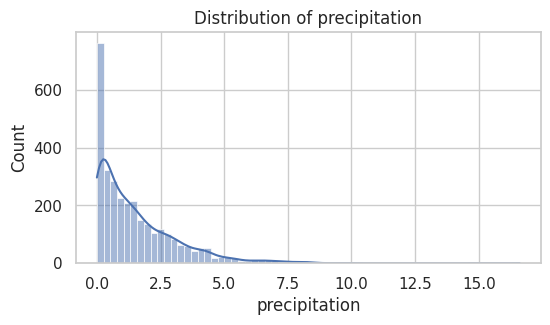

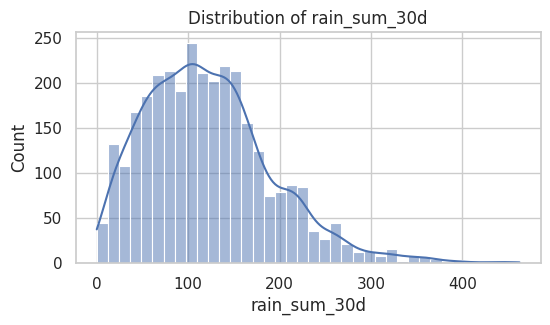

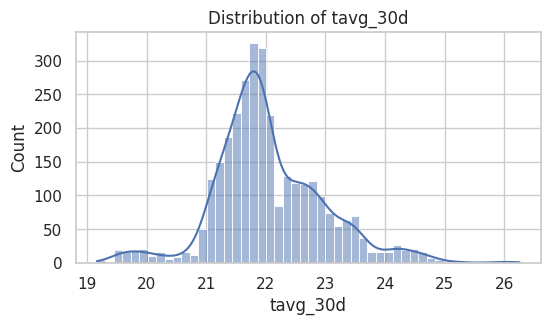

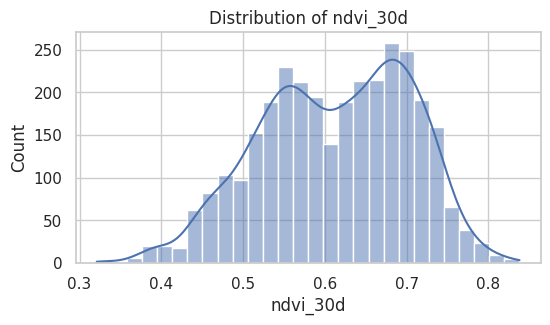

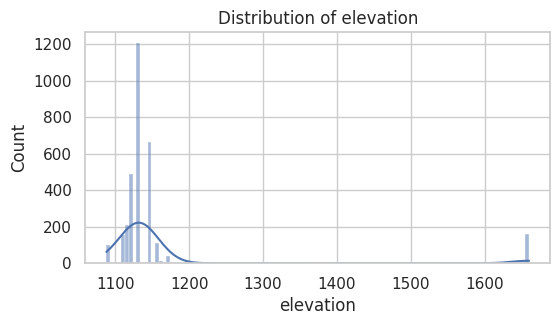

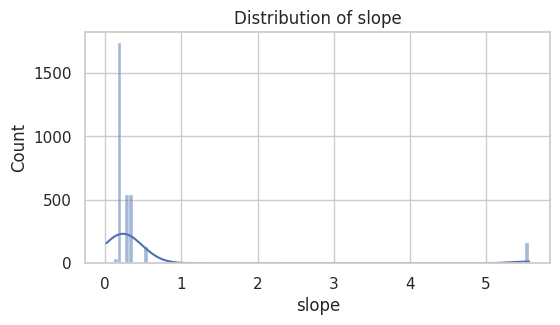

In [10]:

# Inspect some original and downloaded climate features
features_to_plot = [
    "age",
    "avg_temperature",
    "precipitation",
    "rain_sum_30d",
    "tavg_30d",
    "ndvi_30d",
    "elevation",
    "slope"
]

for col in features_to_plot:
    if col in train.columns:
        plt.figure(figsize=(6, 3))
        sns.histplot(train[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()


In [11]:
# Taux de classe 1 par tranche d'âge
age_bins = [0, 5, 15, 25, 35, 45, 55, 65, 75, np.inf]
age_labels = ["0-4", "5-14", "15-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"]

age_analysis = train[["age", TARGET]].copy()
age_analysis["age_group"] = pd.cut(
    age_analysis["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_summary = (
    age_analysis
    .groupby("age_group", observed=False)[TARGET]
    .agg(class_1_rate="mean", count="size")
    .reset_index()
)

age_summary

,age_group,class_1_rate,count
0,0-4,0.836122,1733
1,5-14,0.683761,117
2,15-24,0.416667,120
3,25-34,0.544872,156
4,35-44,0.542169,166
5,45-54,0.503226,155
6,55-64,0.360000,125
7,65-74,0.265957,188
8,75+,0.310881,386



## 🧹 Preprocessing and feature engineering

We keep the baseline simple and use:

- the original challenge features
- the downloaded climate/environmental features
- a few easy engineered features from `deathdate`


In [12]:

train_df = train.copy()
test_df = test.copy()

# Convert dates
train_df["deathdate"] = pd.to_datetime(train_df["deathdate"], errors="coerce")
test_df["deathdate"] = pd.to_datetime(test_df["deathdate"], errors="coerce")

# Date features: preserve the circular nature of the calendar
for df_ in [train_df, test_df]:
    df_["day_of_year"] = df_["deathdate"].dt.dayofyear
    df_["day_of_year_sin"] = np.sin(2 * np.pi * df_["day_of_year"] / 365.25)
    df_["day_of_year_cos"] = np.cos(2 * np.pi * df_["day_of_year"] / 365.25)
    df_["year"] = df_["deathdate"].dt.year
    df_["month"] = df_["deathdate"].dt.month
    df_["season"] = ((df_["month"] % 12) // 3).astype("Int64")
    df_["temperature_range"] = df_["max_temperature"] - df_["min_temperature"]
    df_["is_rainy_day_current"] = (df_["precipitation"] > 0).astype(int)

    # Spatial features: retain the original coordinates and add coarse, unsupervised groups
    df_["latitude_grid"] = df_["latitude"].round(1)
    df_["longitude_grid"] = df_["longitude"].round(1)
    df_["spatial_grid"] = (
        df_["latitude_grid"].astype("string") + "_" +
        df_["longitude_grid"].astype("string")
    )
    df_["location_region"] = df_["location"].str.extract(
        r"([^,]+ Region),\s*Uganda$", expand=False
    ).fillna(df_["zone"])

# Drop only the raw date after extracting its information
train_df = train_df.drop(columns=["deathdate"])
test_df = test_df.drop(columns=["deathdate"])

train_df.head()

,ID,zone,gender,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,location,is_climate_sensitive,elevation,hot_days_30d,max_daily_rain_30d,ndvi_30d,ndvi_90d,rain_days_30d,rain_sum_30d,rain_sum_7d,rain_sum_90d,slope,tavg_30d,tavg_7d,tavg_90d,temp_range_mean_30d,tmax_30d,tmin_30d,day_of_year,day_of_year_sin,day_of_year_cos,year,month,season,temperature_range,is_rainy_day_current,latitude_grid,longitude_grid,spatial_grid,location_region
0,ID_1FE951BD,Rural,Male,30.0,21.137037,25.569017,18.451642,0.951601,0.584646,33.546344,"Izimba, Iganga, Uganda",1,1114,0,20.394434,0.72205,0.72910,18,175.264057,28.419111,421.992750,0.168545,21.425953,22.012127,21.043539,7.897970,27.608331,16.132043,275,-0.999833,0.018277,2007,10,3,7.117375,1,0.6,33.5,0.6_33.5,Rural
1,ID_5927A443,Rural,Male,2.0,24.062790,29.312026,18.977212,0.053352,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1,1145,0,16.994602,0.60815,0.66985,7,71.885960,0.000000,268.439276,0.299996,22.129209,23.021381,21.992129,8.735769,29.251932,15.591455,5,0.085906,0.996303,2008,1,0,10.334814,1,0.5,33.5,0.5_33.5,Rural
2,ID_C4E67025,Rural,Female,31.0,22.407868,26.746058,18.112977,0.090349,0.573420,33.483655,"Buluza, Iganga, Uganda",1,1145,0,15.661628,0.59290,0.61335,20,108.145379,35.970423,242.081887,0.299996,21.990516,21.557252,22.220307,7.694241,29.083597,17.420068,45,0.699079,0.715044,2008,2,0,8.633080,1,0.6,33.5,0.6_33.5,Rural
3,ID_44DC5CE9,Rural,Female,1.0,23.315198,28.056889,18.955708,0.286814,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1,1145,0,15.661628,0.59290,0.61335,19,98.524518,29.091067,229.370640,0.299996,22.032392,21.693581,22.231408,7.718027,29.083597,17.420068,46,0.711276,0.702913,2008,2,0,9.101181,1,0.5,33.5,0.5_33.5,Rural
4,ID_33C677BB,Rural,Female,69.0,23.315198,28.056889,18.955708,0.286814,1.072343,34.226647,"Magada, Mbale City, Bugisa sub-region, Eastern...",0,1660,0,13.468142,0.53380,0.71580,13,84.030272,25.698621,186.079130,5.565486,20.143552,20.141416,20.510054,10.152887,28.300394,12.632257,46,0.711276,0.702913,2008,2,0,9.101181,1,1.1,34.2,1.1_34.2,Eastern Region


In [13]:

# Define target and features
X = train_df.drop(columns=[TARGET, ID_COL])
y = train_df[TARGET]

X_test = test_df.drop(columns=[ID_COL])

categorical_features = [c for c in X.columns if X[c].dtype == "object"]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("Categorical features:", categorical_features)
print("\nNumber of numeric features:", len(numeric_features))
print("\nA few numeric features:", numeric_features[:20])


Categorical features: ['zone', 'gender', 'location', 'location_region']

Number of numeric features: 34

A few numeric features: ['age', 'avg_temperature', 'max_temperature', 'min_temperature', 'precipitation', 'latitude', 'longitude', 'elevation', 'hot_days_30d', 'max_daily_rain_30d', 'ndvi_30d', 'ndvi_90d', 'rain_days_30d', 'rain_sum_30d', 'rain_sum_7d', 'rain_sum_90d', 'slope', 'tavg_30d', 'tavg_7d', 'tavg_90d']



## ✂️ Train / Validation Split

We create a validation set to estimate baseline performance before generating a submission.


In [14]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)


X_train shape: (2516, 38)
X_val shape: (630, 38)



## 🤖 Baseline Model

We use Logistic Regression as a simple and interpretable baseline.

Because the challenge metric includes both **F1** and **ROC-AUC**, this is a good baseline model to start with before trying stronger methods such as Random Forest, LightGBM, XGBoost, or CatBoost.


In [15]:
# Keep location: it is evaluated as a categorical spatial feature.
print("Spatial categorical feature retained:", "location" in categorical_features)
categorical_features

Spatial categorical feature retained: True


['zone', 'gender', 'location', 'location_region']

In [16]:
# Keep latitude and longitude so their predictive value can be measured.
print("Latitude retained:", "latitude" in numeric_features)
print("Longitude retained:", "longitude" in numeric_features)
numeric_features

Latitude retained: True
Longitude retained: True


['age',
 'avg_temperature',
 'max_temperature',
 'min_temperature',
 'precipitation',
 'latitude',
 'longitude',
 'elevation',
 'hot_days_30d',
 'max_daily_rain_30d',
 'ndvi_30d',
 'ndvi_90d',
 'rain_days_30d',
 'rain_sum_30d',
 'rain_sum_7d',
 'rain_sum_90d',
 'slope',
 'tavg_30d',
 'tavg_7d',
 'tavg_90d',
 'temp_range_mean_30d',
 'tmax_30d',
 'tmin_30d',
 'day_of_year',
 'day_of_year_sin',
 'day_of_year_cos',
 'year',
 'month',
 'season',
 'temperature_range',
 'is_rainy_day_current',
 'latitude_grid',
 'longitude_grid',
 'spatial_grid']

In [17]:
from sklearn import clone
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ('scaler', StandardScaler())
            ]),
            numeric_features
        )
    ]
)


# Pipeline add different model and hyperparameter tuning if needed
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.5, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Build one complete pipeline for each model
pipelines = {}

for model_name, model in models.items():
    pipelines[model_name] = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

# Validation croisée stratifiée en 5 folds
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# We will fit one complete pipeline for each model
model_results = []
oof_predictions = {}

for model_name, model_pipeline in pipelines.items():
    print(f"Évaluation de {model_name}...")

    # Probabilités out-of-fold
    # Correct feature types: spatial_grid is categorical
    categorical_features_fixed = list(dict.fromkeys(
        categorical_features + ["spatial_grid"]
    ))
    numeric_features_fixed = [
        col for col in numeric_features
        if col != "spatial_grid"
    ]

    fixed_preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_features_fixed
            ),
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numeric_features_fixed
            )
        ]
    )

    fixed_pipeline = Pipeline([
        ("preprocess", fixed_preprocessor),
        ("model", clone(model_pipeline.named_steps["model"]))
    ])

    oof_proba = cross_val_predict(
        fixed_pipeline,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    oof_predictions[model_name] = oof_proba

    # Recherche du meilleur seuil selon le score officiel
    thresholds = np.arange(0.10, 0.91, 0.01)
    threshold_scores = []

    roc_auc = roc_auc_score(y, oof_proba)

    for threshold in thresholds:
        oof_pred = (oof_proba >= threshold).astype(int)
        f1 = f1_score(y, oof_pred)
        final_score = 0.60 * f1 + 0.40 * roc_auc

        threshold_scores.append({
            "threshold": threshold,
            "f1": f1,
            "roc_auc": roc_auc,
            "final_score": final_score
        })

    threshold_scores = pd.DataFrame(threshold_scores)

    best_result = threshold_scores.loc[
        threshold_scores["final_score"].idxmax()
    ]

    model_results.append({
        "model": model_name,
        "threshold": best_result["threshold"],
        "f1": best_result["f1"],
        "roc_auc": best_result["roc_auc"],
        "final_score": best_result["final_score"]
    })

model_results = (
    pd.DataFrame(model_results)
    .sort_values("final_score", ascending=False)
    .reset_index(drop=True)
)

model_results

Évaluation de LogisticRegression...
Évaluation de RandomForest...
Évaluation de XGBoost...


/home/henintsoa/myenv/venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [18:37:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/henintsoa/myenv/venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [18:37:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/henintsoa/myenv/venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [18:37:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/henintsoa/myenv/venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [18:37:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/henintsoa/myenv/venv/lib/pytho

,model,threshold,f1,roc_auc,final_score
0,LogisticRegression,0.31,0.817834,0.795196,0.808779
1,RandomForest,0.45,0.803085,0.784220,0.795539
2,XGBoost,0.10,0.801411,0.782106,0.793689


In [18]:
# Ablation study: compare the full feature set with a version without climate variables
climate_columns = [
    column for column in X.columns
    if (
        column in climate_features.columns
        or column in {
            "avg_temperature",
            "max_temperature",
            "min_temperature",
            "precipitation",
            "temperature_range",
            "is_rainy_day_current"
        }
    )
]

X_without_climate = X.drop(columns=climate_columns, errors="ignore")

ablation_results = []

for feature_set_name, feature_data in {
    "all_features": X,
    "without_climate": X_without_climate
}.items():
    feature_categorical = [c for c in feature_data.columns if feature_data[c].dtype == "object"]
    feature_numeric = [c for c in feature_data.columns if c not in feature_categorical]

    feature_preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                feature_categorical
            ),
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                feature_numeric
            )
        ]
    )

    for model_name, model in models.items():
        ablation_pipeline = Pipeline([
            ("preprocess", feature_preprocessor),
            ("model", model)
        ])
        # Rebuild feature groups, including pandas string/category columns
        feature_categorical = [
            column for column in feature_data.columns
            if (
            pd.api.types.is_object_dtype(feature_data[column])
            or pd.api.types.is_string_dtype(feature_data[column])
            or pd.api.types.is_categorical_dtype(feature_data[column])
            )
        ]
        feature_numeric = [
            column for column in feature_data.columns
            if column not in feature_categorical
        ]

        feature_preprocessor = ColumnTransformer(
            transformers=[
            (
                "cat",
                Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                feature_categorical
            ),
            (
                "num",
                Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
                ]),
                feature_numeric
            )
            ]
        )

        ablation_pipeline = Pipeline([
            ("preprocess", feature_preprocessor),
            ("model", clone(model))
        ])

        ablation_proba = cross_val_predict(
            ablation_pipeline,
            feature_data,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1
        )[:, 1]
        ablation_auc = roc_auc_score(y, ablation_proba)

        best_ablation_score = None
        for threshold in np.arange(0.10, 0.91, 0.01):
            ablation_pred = (ablation_proba >= threshold).astype(int)
            ablation_f1 = f1_score(y, ablation_pred)
            score = 0.60 * ablation_f1 + 0.40 * ablation_auc
            candidate = {
                "feature_set": feature_set_name,
                "model": model_name,
                "f1": ablation_f1,
                "roc_auc": ablation_auc,
                "final_score": score,
                "n_features": feature_data.shape[1]
            }
            if best_ablation_score is None or score > best_ablation_score["final_score"]:
                best_ablation_score = candidate

        ablation_results.append(best_ablation_score)

ablation_results = (
    pd.DataFrame(ablation_results)
    .sort_values("final_score", ascending=False)
    .reset_index(drop=True)
)

print("Climate columns removed:", climate_columns)
ablation_results

/tmp/ipykernel_105487/4051067648.py:60: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(feature_data[column])
/tmp/ipykernel_105487/4051067648.py:60: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(feature_data[column])
/tmp/ipykernel_105487/4051067648.py:60: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(feature_data[column])
/home/henintsoa/myenv/venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [18:38:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/henintsoa

Climate columns removed: ['avg_temperature', 'max_temperature', 'min_temperature', 'precipitation', 'elevation', 'hot_days_30d', 'max_daily_rain_30d', 'ndvi_30d', 'ndvi_90d', 'rain_days_30d', 'rain_sum_30d', 'rain_sum_7d', 'rain_sum_90d', 'slope', 'tavg_30d', 'tavg_7d', 'tavg_90d', 'temp_range_mean_30d', 'tmax_30d', 'tmin_30d', 'temperature_range', 'is_rainy_day_current']


,feature_set,model,f1,roc_auc,final_score,n_features
0,without_climate,LogisticRegression,0.818344,0.796829,0.809738,16
1,all_features,LogisticRegression,0.817834,0.795196,0.808779,38
2,all_features,XGBoost,0.801411,0.782106,0.793689,38
3,all_features,RandomForest,0.798839,0.783167,0.792570,38
4,without_climate,RandomForest,0.801040,0.776523,0.791233,16
5,without_climate,XGBoost,0.789279,0.757257,0.776470,16


In [19]:
# Sélectionner le meilleur modèle
best_model_name = model_results.loc[0, "model"]
best_threshold = model_results.loc[0, "threshold"]

best_pipeline = pipelines[best_model_name]
best_oof_proba = oof_predictions[best_model_name]
best_oof_pred = (best_oof_proba >= best_threshold).astype(int)

print(f"Meilleur modèle : {best_model_name}")
print(f"Meilleur seuil : {best_threshold:.2f}")
print(f"F1 : {f1_score(y, best_oof_pred):.6f}")
print(f"ROC-AUC : {roc_auc_score(y, best_oof_proba):.6f}")
print(
    f"Score final : "
    f"{0.60 * f1_score(y, best_oof_pred) + 0.40 * roc_auc_score(y, best_oof_proba):.6f}"
)

Meilleur modèle : LogisticRegression
Meilleur seuil : 0.31
F1 : 0.817834
ROC-AUC : 0.795196
Score final : 0.808779



## 📈 Validation Performance

Official metric:

**Final Score = 0.60 × F1 + 0.40 × ROC-AUC**

Participants submit:
- `TargetF1`: binary prediction
- `TargetRAUC`: probability prediction


In [20]:
# Évaluation avec les prédictions out-of-fold
# Le modèle et le seuil ont été sélectionnés avec la validation croisée

best_oof_pred = (best_oof_proba >= best_threshold).astype(int)

f1 = f1_score(y, best_oof_pred)
auc = roc_auc_score(y, best_oof_proba)
final_score = 0.60 * f1 + 0.40 * auc

print(f"Modèle sélectionné : {best_model_name}")
print(f"Seuil sélectionné : {best_threshold:.2f}")
print(f"F1-score OOF : {f1:.6f}")
print(f"ROC-AUC OOF : {auc:.6f}")
print(f"Score final OOF : {final_score:.6f}")

print("\nClassification Report:")
print(classification_report(y, best_oof_pred, digits=3))

Modèle sélectionné : LogisticRegression
Seuil sélectionné : 0.31
F1-score OOF : 0.817834
ROC-AUC OOF : 0.795196
Score final OOF : 0.808779

Classification Report:
              precision    recall  f1-score   support

           0      0.693     0.474     0.563      1099
           1      0.759     0.887     0.818      2047

    accuracy                          0.743      3146
   macro avg      0.726     0.681     0.690      3146
weighted avg      0.736     0.743     0.729      3146



In [21]:
# plt.figure(figsize=(10, 5))

# plt.plot(
#     threshold_results["threshold"],
#     threshold_results["f1"],
#     label="F1",
#     linewidth=2
# )

# plt.plot(
#     threshold_results["threshold"],
#     threshold_results["final_score"],
#     label="Score final",
#     linewidth=2
# )

# plt.axvline(
#     best_threshold,
#     color="red",
#     linestyle="--",
#     label=f"Meilleur seuil = {best_threshold:.2f}"
# )

# plt.xlabel("Seuil de classification")
# plt.ylabel("Score")
# plt.title("Performance selon le seuil de classification")
# plt.legend()
# plt.show()

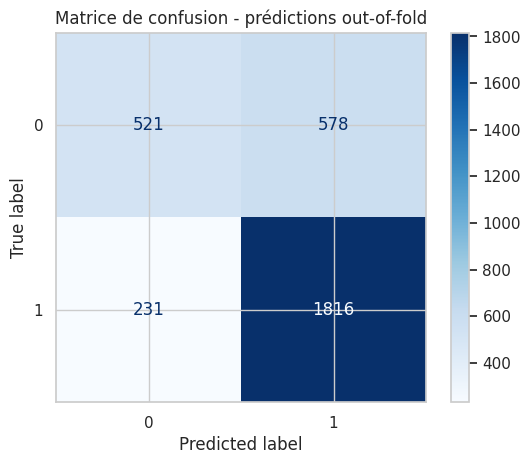

In [22]:
cm = confusion_matrix(y, best_oof_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - prédictions out-of-fold")
plt.show()


## 📊 Feature Importance

We use permutation importance to see which features are most helpful to the baseline model.


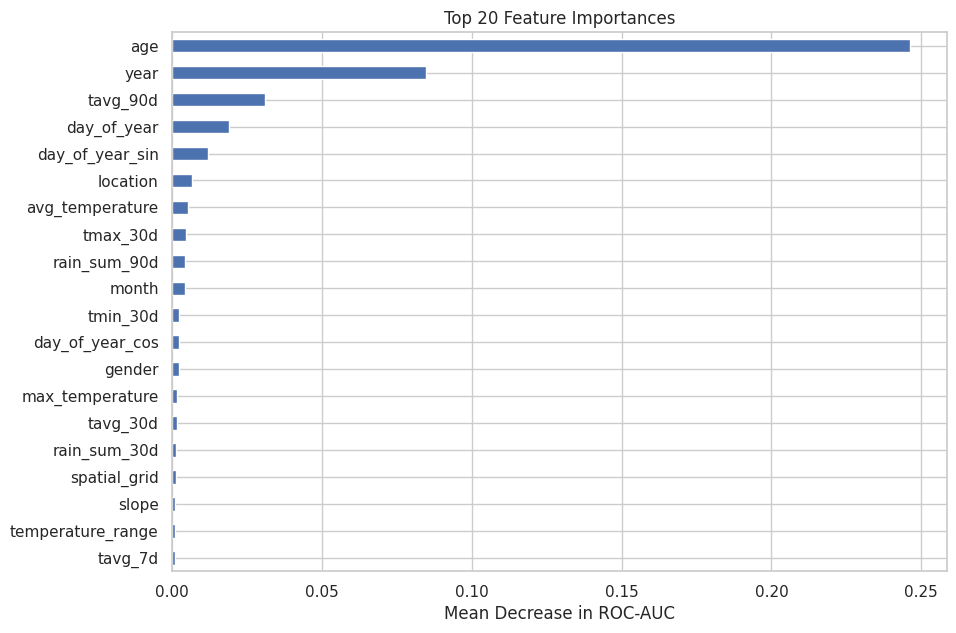

In [23]:
from sklearn.base import clone

# Identifier correctement les variables catégorielles et numériques
importance_categorical = [
    column for column in X.columns
    if not pd.api.types.is_numeric_dtype(X[column])
]

importance_numeric = [
    column for column in X.columns
    if pd.api.types.is_numeric_dtype(X[column])
]

importance_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            importance_categorical
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            importance_numeric
        )
    ]
)

# Reconstruire le pipeline avec le meilleur modèle
importance_pipeline = Pipeline([
    ("preprocess", importance_preprocessor),
    ("model", clone(best_pipeline.named_steps["model"]))
])

# Entraîner le pipeline corrigé
importance_pipeline.fit(X, y)

# Calculer les importances par permutation
result = permutation_importance(
    importance_pipeline,
    X,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)

importances = pd.Series(
    result.importances_mean,
    index=X.columns
)

(
    importances
    .sort_values(ascending=False)
    .head(20)
    .sort_values()
    .plot(kind="barh", figsize=(10, 7))
)

plt.title("Top 20 Feature Importances")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.show()


## 🚀 Train on Full Data and Predict on Test

Now retrain the baseline on the full training data and generate the submission file.


In [25]:
from sklearn.base import clone

# Identifier automatiquement les types de variables
final_categorical = [
    column for column in X.columns
    if not pd.api.types.is_numeric_dtype(X[column])
]

final_numeric = [
    column for column in X.columns
    if pd.api.types.is_numeric_dtype(X[column])
]

# Préprocesseur corrigé
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            final_categorical
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            final_numeric
        )
    ]
)

# Reconstruire le meilleur pipeline avec le modèle sélectionné
best_pipeline = Pipeline([
    ("preprocess", final_preprocessor),
    ("model", clone(models[best_model_name]))
])

# Entraîner le meilleur modèle sur toutes les données
best_pipeline.fit(X, y)

# Prédictions sur le jeu de test
test_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_pred_label = (test_pred_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET_F1: test_pred_label,
    TARGET_RAUC: test_pred_proba
})

submission.head()

,ID,TargetF1,TargetRAUC
0,ID_E760D84B,1,0.388497
1,ID_6EDEA907,1,0.562191
2,ID_B9FFC8D8,1,0.334256
3,ID_74C6C94E,0,0.151025
4,ID_0E02825D,1,0.775698


In [26]:
submission.to_csv("final_submission.csv", index=False)
print("Submission file saved as final_submission.csv")


Submission file saved as final_submission.csv



## ✅ What’s Next?

This is still only a starter baseline. You can improve it by:

- trying stronger models such as Random Forest, LightGBM, XGBoost, or CatBoost
- tuning the threshold used for `TargetF1`
- engineering richer spatial features
- comparing models with and without downloaded climate features
- validating more carefully across space

Good luck, and happy modelling! 🚀
